In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
FILE_PATH = "data/output.csv"
df = pd.read_csv(FILE_PATH)

In [3]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,province,date,day,month,year,day_of_week,season,is_holiday
0,TXN_9687814,Coffee,2.0,3.5,7.0,Digital Wallet,In-store,2023-09-28,British Columbia,2023-09-28,28,9,2023,Thursday,fall,False
1,TXN_7668262,Donut,1.0,2.0,2.0,Digital Wallet,In-store,2023-11-27,British Columbia,2023-11-27,27,11,2023,Monday,fall,False
2,TXN_7321503,Tea,1.0,3.0,3.0,Credit Card,Takeaway,2023-09-15,British Columbia,2023-09-15,15,9,2023,Friday,fall,False
3,TXN_7075658,Coffee,4.0,3.5,14.0,Credit Card,In-store,2023-10-21,Manitoba,2023-10-21,21,10,2023,Saturday,fall,False
4,TXN_3811286,Salad,5.0,9.0,45.0,Credit Card,Takeaway,2023-10-04,Manitoba,2023-10-04,4,10,2023,Wednesday,fall,False


## Basic Analysis

In [4]:
# Total Revenue
print(df['total_spent'].sum())
# Total Transactions
print(df['transaction_id'].count())
# Avg num of transcations per day
print()
# Avg Transaction Spent
print(round(df['total_spent'].mean(), 2))
# Total Selling Item
products_sold = df[['item', 'quantity']].groupby('item')['quantity'].sum()
print(products_sold.idxmax(), products_sold.max()) # Total quantity per item then get max
# Peak Selling Month (in Revenue)
monthly_rev = df[['month', 'total_spent']].groupby('month')['total_spent'].sum()
print(monthly_rev.idxmax(), monthly_rev.max())
# Next Month Forecast
print('TBD')


68627.5
7932

8.65
Coffee 4366.0
6 6319.5
TBD


## Sales Trends

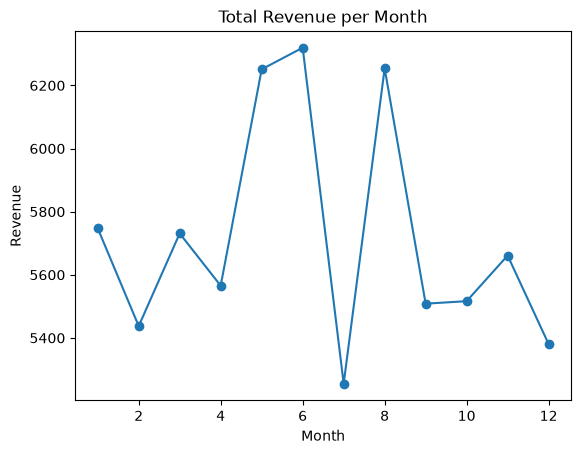

In [5]:
rev_month = df.groupby("month")["total_spent"].sum()

rev_month.plot(kind="line", marker="o")
plt.title("Total Revenue per Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


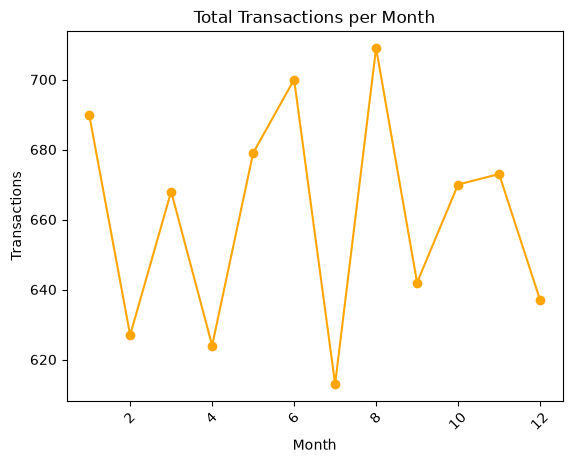

In [6]:

txn_month = df.groupby("month")["transaction_id"].count()

txn_month.plot(kind="line", marker="o", color="orange")
plt.title("Total Transactions per Month")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.show()


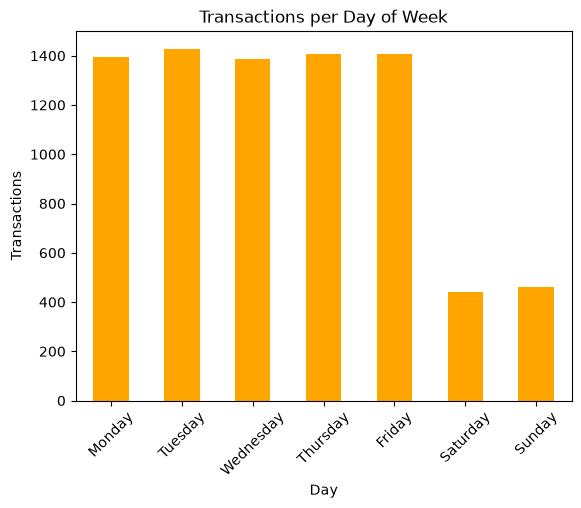

In [7]:

txn_dow = df.groupby("day_of_week")["transaction_id"].count()
txn_dow = txn_dow.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

txn_dow.plot(kind="bar", color="orange")
plt.title("Transactions per Day of Week")
plt.ylabel("Transactions")
plt.xlabel("Day")
plt.xticks(rotation=45)
plt.show()


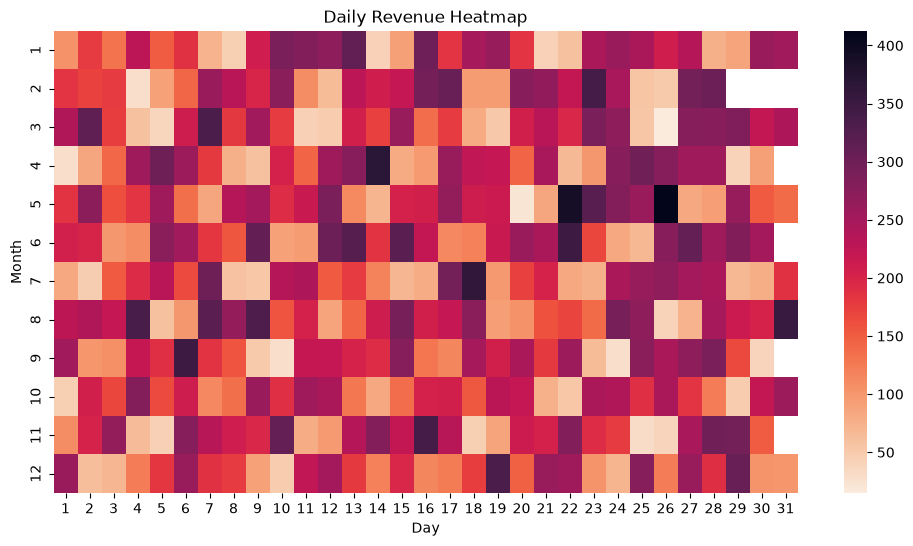

In [8]:
# Might be best to skip this lol
heatmap_data = df.groupby(["month", "day"])["total_spent"].sum().unstack()

holiday_mask = df[df["is_holiday"]] # not sure how to use the mask

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='rocket_r')

plt.title("Daily Revenue Heatmap")
plt.xlabel("Day")
plt.ylabel("Month")
plt.show()

## Product Performance

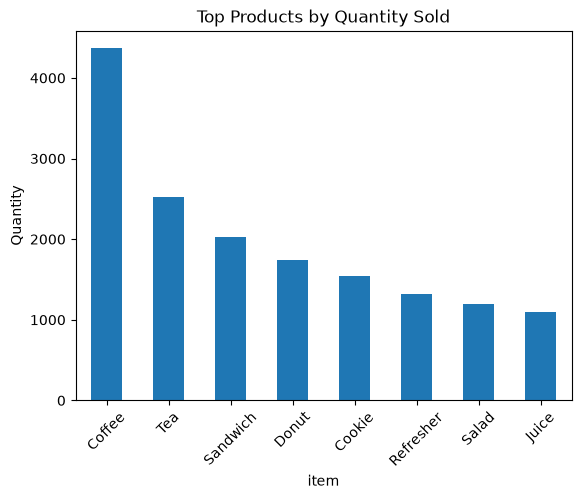

In [9]:
top_items = df.groupby("item")["quantity"].sum().sort_values(ascending=False)#.head(10)

top_items.plot(kind="bar")
plt.title("Top Products by Quantity Sold")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.show()

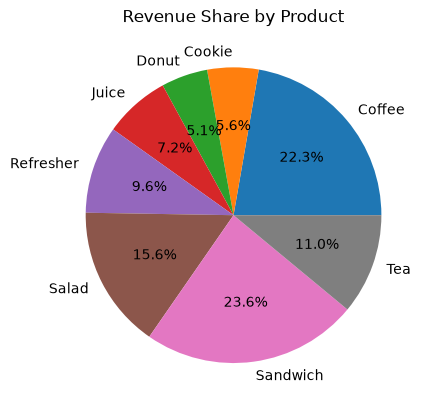

In [10]:
rev_item = df.groupby("item")["total_spent"].sum()

rev_item.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue Share by Product")
plt.ylabel("")
plt.show()


## Location Insights

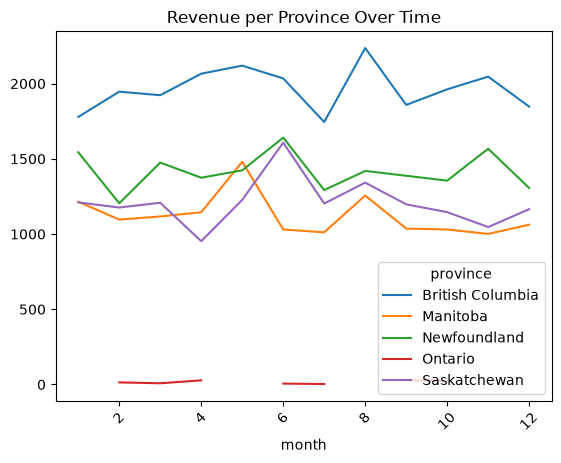

In [11]:
prov_month = df.groupby(["month", "province"])["total_spent"].sum().unstack()

prov_month.plot()
plt.title("Revenue per Province Over Time")
plt.xticks(rotation=45)
plt.show()

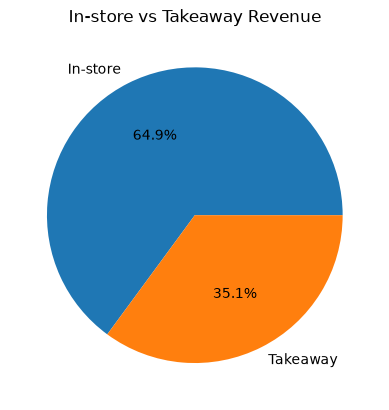

In [12]:
loc_split = df.groupby("location")["total_spent"].sum()

loc_split.plot(kind="pie", autopct="%1.1f%%")
plt.title("In-store vs Takeaway Revenue")
plt.ylabel("")
plt.show()

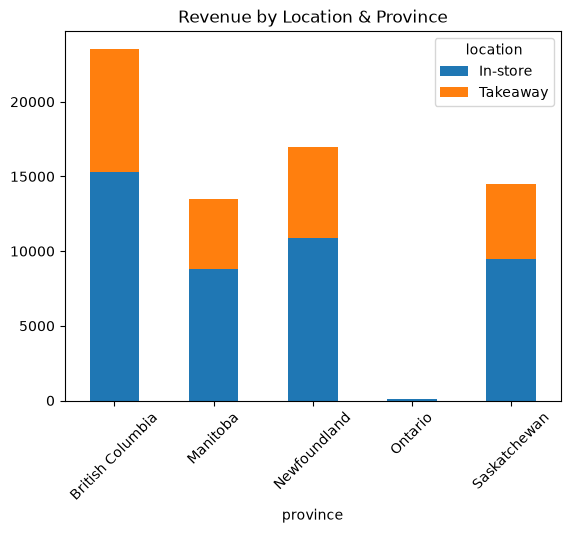

In [13]:
loc_prov = df.groupby(["province", "location"])["total_spent"].sum().unstack()

loc_prov.plot(kind="bar", stacked=True)
plt.title("Revenue by Location & Province")
plt.xticks(rotation=45)
plt.show()


## Payment Behaviour

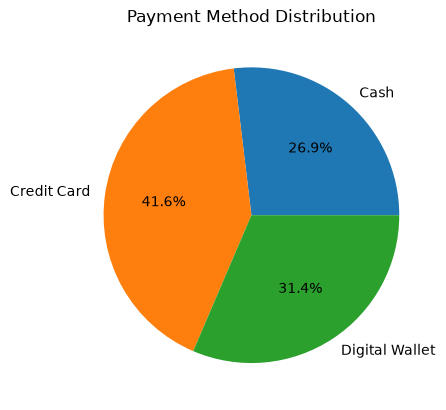

In [14]:

pay = df.groupby("payment_method")["total_spent"].sum()

pay.plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()


## Advanced Metrics

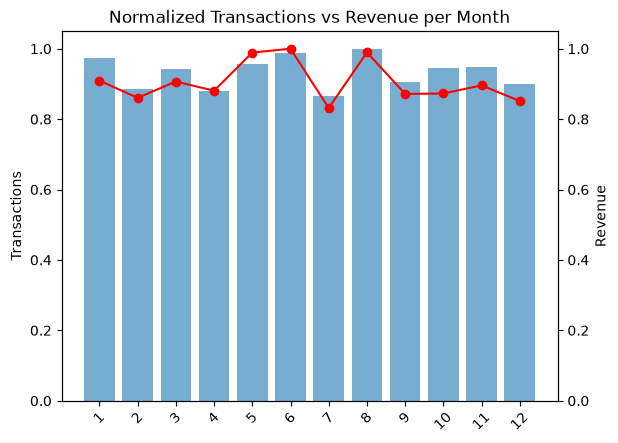

In [15]:
# note: graphs dont scale well together should probably also skip
monthly = df.groupby("month").agg({
    "transaction_id": "count",
    "total_spent": "sum"
}).reset_index()

monthly["txn_norm"] = monthly["transaction_id"] / monthly["transaction_id"].max()
monthly["rev_norm"] = monthly["total_spent"] / monthly["total_spent"].max()

x = range(len(monthly))  # shared x positions

fig, ax1 = plt.subplots()

# Bars (transactions)
ax1.bar(x, monthly["txn_norm"], alpha=0.6)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Transactions")

# Line (revenue)
ax2 = ax1.twinx()
ax2.plot(x, monthly["rev_norm"], color="red", marker="o")
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Revenue")

# Fix x-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(monthly["month"], rotation=45)

plt.title("Normalized Transactions vs Revenue per Month")
plt.show()

## Top 3 Items Sold by Province

In [16]:
# Step 1: Aggregate
popular_qty = (
    df.groupby(["province", "item"])["quantity"]
    .sum()
    .reset_index()
)

# Step 3: Sort and rank within province
popular_qty = popular_qty.sort_values(
    ["province", "quantity"], ascending=[True, False]
)

popular_qty["rank"] = popular_qty.groupby("province").cumcount() + 1

# Keep only top 3
top3 = popular_qty[popular_qty["rank"] <= 3]

# Step 4: Pivot into columns
result_qty = top3.pivot(
    index="province",
    columns="rank",
    values=["item", "quantity"]
)

# Flatten column names
result_qty.columns = [
    f"{col[0]}_{col[1]}" for col in result_qty.columns
]

print(result_qty.reset_index())

           province  item_1     item_2    item_3 quantity_1 quantity_2  \
0  British Columbia  Coffee        Tea  Sandwich     1540.0      813.0   
1          Manitoba  Coffee        Tea  Sandwich      866.0      512.0   
2      Newfoundland  Coffee        Tea  Sandwich     1097.0      631.0   
3           Ontario  Coffee  Refresher  Sandwich       10.0        4.0   
4      Saskatchewan  Coffee        Tea  Sandwich      853.0      559.0   

  quantity_3  
0      705.0  
1      369.0  
2      519.0  
3        3.0  
4      432.0  


In [17]:
# Aggregate revenue
popular_rev = (
    df.groupby(["province", "item"])["total_spent"]
    .sum()
    .reset_index()
)

# % of revenue
popular_rev["pct_revenue"] = (
    popular_rev["total_spent"]
    / popular_rev.groupby("province")["total_spent"].transform("sum")
    * 100
)

# Sort + rank
popular_rev = popular_rev.sort_values(
    ["province", "total_spent"], ascending=[True, False]
)

popular_rev["rank"] = popular_rev.groupby("province").cumcount() + 1

# Top 3
top3_rev = popular_rev[popular_rev["rank"] <= 3]

# Pivot
result_rev = top3_rev.pivot(
    index="province",
    columns="rank",
    values=["item", "total_spent", "pct_revenue"]
)

# Flatten columns
result_rev.columns = [
    f"{col[0]}_{col[1]}" for col in result_rev.columns
]

print(result_rev.reset_index())

           province    item_1    item_2     item_3 total_spent_1  \
0  British Columbia  Sandwich    Coffee      Salad        5640.0   
1          Manitoba    Coffee  Sandwich      Salad        3031.0   
2      Newfoundland  Sandwich    Coffee      Salad        4152.0   
3           Ontario    Coffee  Sandwich  Refresher          35.0   
4      Saskatchewan  Sandwich    Coffee      Salad        3456.0   

  total_spent_2 total_spent_3 pct_revenue_1 pct_revenue_2 pct_revenue_3  
0        5390.0        3537.0     23.935324     22.874361     15.010504  
1        2952.0        2205.0     22.482661     21.896673     16.355747  
2        3839.5        2493.0     24.438624     22.599252     14.673769  
3          24.0          20.0     31.674208     21.719457     18.099548  
4        2985.5        2466.0     23.863283     20.614535     17.027447  


## Monthly Metrics

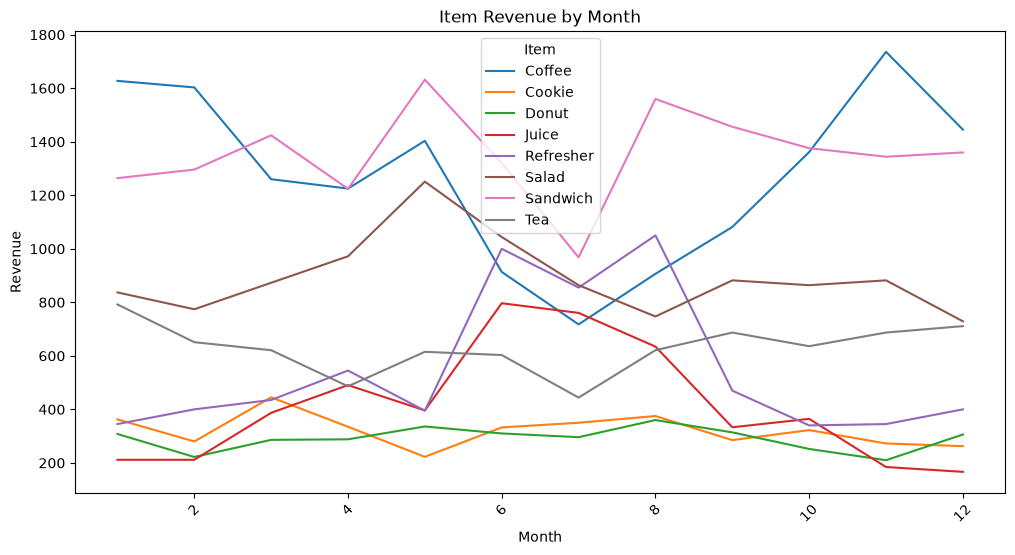

In [18]:
# Aggregate revenue
item_month = (
    df.groupby(["month", "item"])["total_spent"]
    .sum()
    .unstack()
)

# Plot
item_month.plot(figsize=(12,6))
plt.title("Item Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Item")
plt.show()


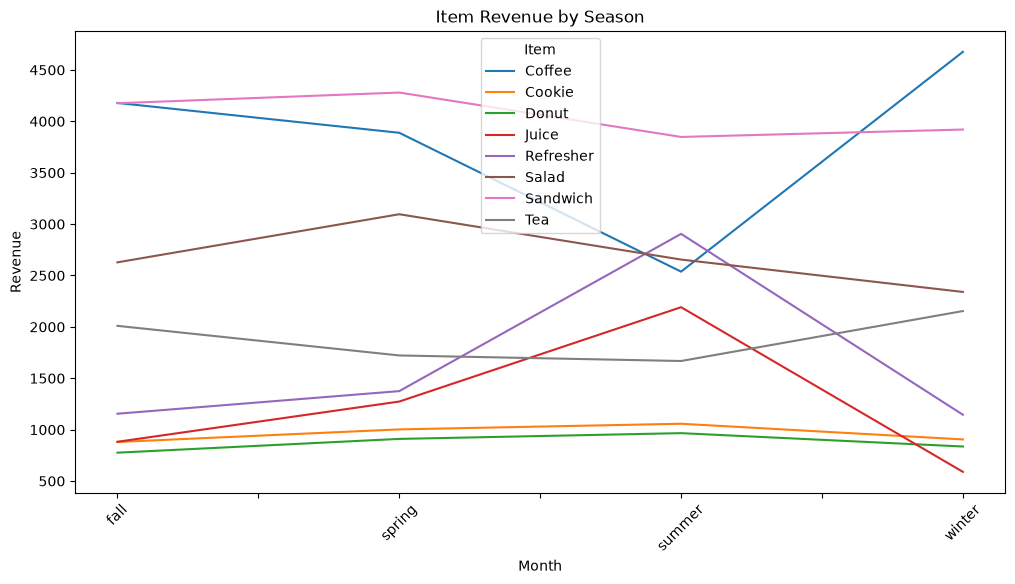

In [19]:
# Aggregate revenue
item_month = (
    df.groupby(["season", "item"])["total_spent"]
    .sum()
    .unstack()
)

# Plot
item_month.plot(figsize=(12,6))
plt.title("Item Revenue by Season")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Item")
plt.show()


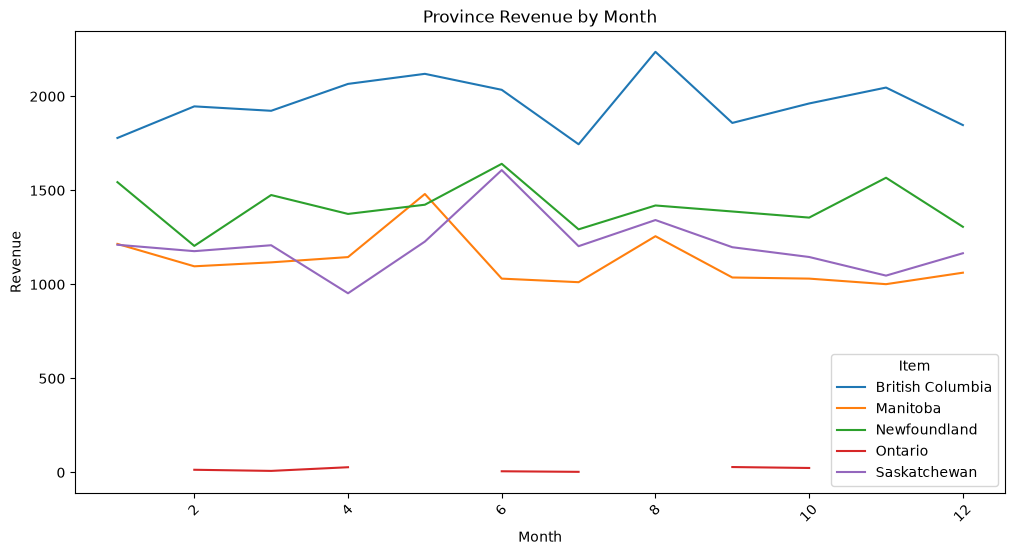

In [20]:
# Aggregate revenue
item_month = (
    df.groupby(["month", "province"])["total_spent"]
    .sum()
    .unstack()
)

# Plot
item_month.plot(figsize=(12,6))
plt.title("Province Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Item")
plt.show()


## Holiday Metrics

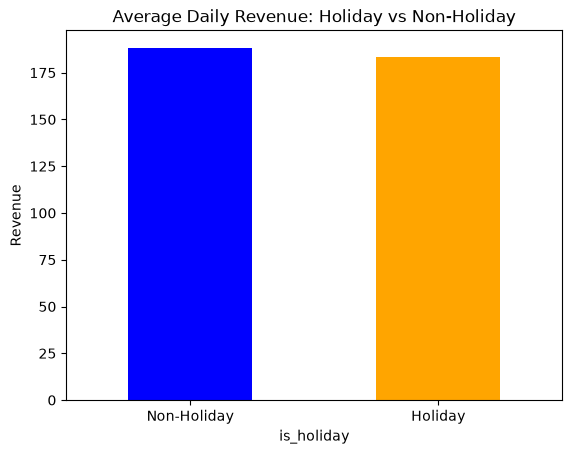

In [21]:
daily = df.groupby(["date", "is_holiday"])["total_spent"].sum().reset_index()
avg = daily.groupby("is_holiday")["total_spent"].mean().rename({
    False: "Non-Holiday",
    True: "Holiday"
})

avg.plot(kind="bar", color=["blue", "orange"])

plt.title("Average Daily Revenue: Holiday vs Non-Holiday")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

In [22]:
daily_txn = df.groupby(["date", "is_holiday"])["transaction_id"].count().reset_index()

sns.boxplot(data=daily_txn, x="is_holiday", y="transactions")

plt.xticks([0,1], ["Non-Holiday", "Holiday"])
plt.title("Transactions: Holiday vs Non-Holiday")
plt.show()

ValueError: Could not interpret value `transactions` for `y`. An entry with this name does not appear in `data`.